In [1]:
import torch
import os
import random
import utils
import data_utils
import json

import cbm
import plots

In [2]:
# change this to the correct model dir, everything else should be taken care of
load_dir = "saved_models/chestxray_cbm_2025_07_06_21_24"
device = "cuda"

with open(os.path.join(load_dir, "args.txt"), "r") as f:
    args = json.load(f)
dataset = args["dataset"]
_, target_preprocess = data_utils.get_target_model(args["backbone"], device)
model = cbm.load_cbm(load_dir, device)

100%|███████████████████████████████████████| 890M/890M [00:18<00:00, 51.7MiB/s]
d:\GitHub\Label-free-CBM\cbm.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  W_c = torc

In [3]:
val_d_probe = dataset+"_val"
cls_file = data_utils.LABEL_FILES[dataset]

val_data_t = data_utils.get_data(val_d_probe, preprocess=target_preprocess)
val_pil_data = data_utils.get_data(val_d_probe)

In [4]:
with open(cls_file, "r") as f:
    classes = f.read().split("\n")

with open(os.path.join(load_dir, "concepts.txt"), "r") as f:
    concepts = f.read().split("\n")

## Measure accuracy

In [5]:
accuracy = utils.get_accuracy_cbm(model, val_data_t, device)
print("Top-1 Accuracy: {:.2f}%".format(accuracy*100))

100%|██████████| 113/113 [05:42<00:00,  3.03s/it]

Top-1 Accuracy: 43.22%


In [6]:
topk_accuracy = utils.get_topk_accuracy_cbm(model, val_data_t, device, k=3)
print("Top-3 Accuracy: {:.2f}%".format(topk_accuracy*100))

100%|██████████| 113/113 [04:20<00:00,  2.31s/it]

Top-3 Accuracy: 66.01%


In [7]:
topk_accuracy = utils.get_topk_accuracy_cbm(model, val_data_t, device, k=5)
print("Top-5 Accuracy: {:.2f}%".format(topk_accuracy*100))

100%|██████████| 113/113 [04:09<00:00,  2.21s/it]

Top-5 Accuracy: 80.54%


## Show final layer weights for some classes

You can build a Sankey diagram of weights by copying the incoming weights printed below into https://sankeymatic.com/build/

In [8]:
to_show = random.choices([i for i in range(len(classes))], k=1)

for i in to_show:
    print("Output class:{} - {}".format(i, classes[i]))
    print("Incoming weights:")
    for j in range(len(concepts)):
        if torch.abs(model.final.weight[i,j])>0.05:
            print("{} [{:.4f}] {}".format(concepts[j], model.final.weight[i,j], classes[i]))

Output class:2 - Infiltration
Incoming weights:
- Air bronchograms [0.0619] Infiltration
- Increased lung opacity [-0.1060] Infiltration
Density of the nodule [-0.0794] Infiltration
Elevated left main bronchus [0.0948] Infiltration
Esophagus [-0.1310] Infiltration
Extension along the chest wall [0.0583] Infiltration
Increased lung density [-0.0868] Infiltration
Irregular or lobulated margins [0.1575] Infiltration
Lung collapse [0.0749] Infiltration
Lung pleura [-0.0804] Infiltration
No pleural effusion [0.1295] Infiltration
Normal heart size and shape [-0.1084] Infiltration
Pleural-based opacities [-0.0577] Infiltration
Respiratory Disease [0.1543] Infiltration
Subpleural reticulation [0.0699] Infiltration
Thoracic spine [-0.1188] Infiltration
Widened mediastinum [-0.2053] Infiltration


In [9]:
to_show = random.choices([i for i in range(len(classes))], k=2)

top_weights, top_weight_ids = torch.topk(model.final.weight, k=5, dim=1)
bottom_weights, bottom_weight_ids = torch.topk(model.final.weight, k=5, dim=1, largest=False)

for i in to_show:
    print("Class {} - {}".format(i, classes[i]))
    out = "Highest weights: "
    for j in range(top_weights.shape[1]):
        idx = int(top_weight_ids[i, j].cpu())
        out += "{}:{:.3f}, ".format(concepts[idx], top_weights[i, j])
    print(out)
    out = "Lowest weights: "
    for j in range(bottom_weights.shape[1]):
        idx = int(bottom_weight_ids[i, j].cpu())
        out += "{}:{:.3f}, ".format(concepts[idx], bottom_weights[i, j])
    print(out + "\n")

Class 4 - Edema
Highest weights: - pulmonary consolidation:0.273, - Lung parenchyma:0.223, Irregular or lobulated margins:0.151, No pleural effusion:0.134, - Enlarged cardiac silhouette:0.129, 
Lowest weights: Widened mediastinum:-0.180, Rib cage:-0.174, Alveolar pattern:-0.143, - Pulmonary nodule:-0.143, Thoracic spine:-0.132, 

Class 2 - Infiltration
Highest weights: Irregular or lobulated margins:0.157, Respiratory Disease:0.154, No pleural effusion:0.129, Elevated left main bronchus:0.095, Lung collapse:0.075, 
Lowest weights: Widened mediastinum:-0.205, Esophagus:-0.131, Thoracic spine:-0.119, Normal heart size and shape:-0.108, - Increased lung opacity:-0.106, 



In [10]:
# Some features may not have any non-zero outgoing weights, 
# i.e. these are not used by the model and should be deleted for better performance
weight_contribs = torch.sum(torch.abs(model.final.weight), dim=0)
print("Num concepts with outgoing weights:{}/{}".format(torch.sum(weight_contribs>1e-5), len(weight_contribs)))

Num concepts with outgoing weights:68/69


## Explain model reasoning for random inputs

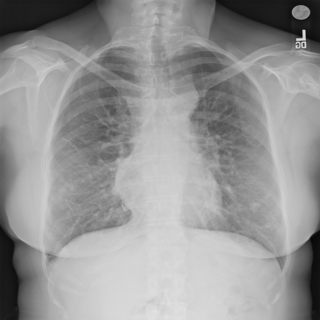

Image:24882 Ground Truth:Nodule
Pred 1: Cardiomegaly (logit: 3.249, conf: 0.616)
Pred 2: Pneumonia (logit: 1.200, conf: 0.079)
Pred 3: Atelectasis (logit: 1.178, conf: 0.078)
Pred 4: Edema (logit: 0.984, conf: 0.064)
Pred 5: Nodule (logit: 0.354, conf: 0.034)


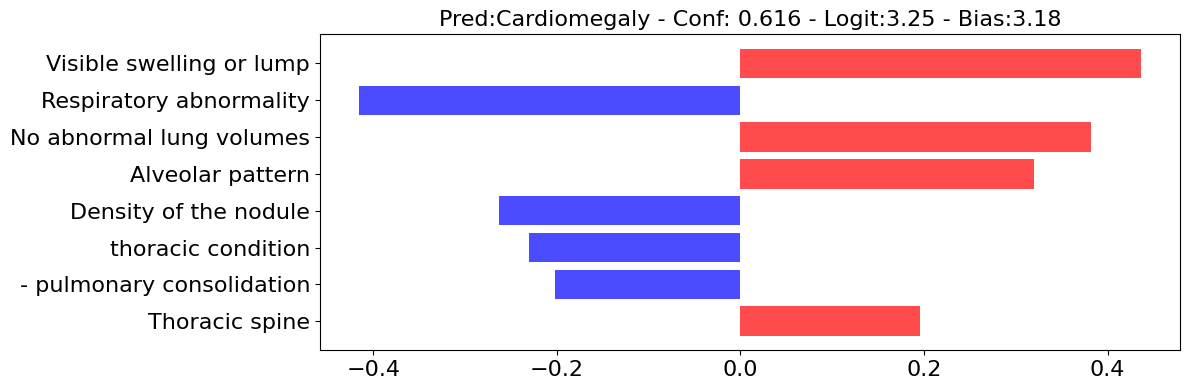

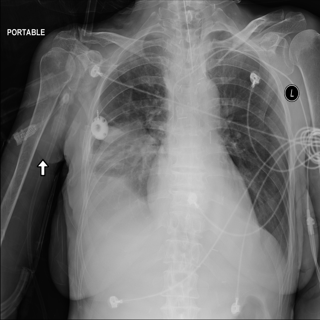

Image:26557 Ground Truth:Mass
Pred 1: Cardiomegaly (logit: 2.430, conf: 0.263)
Pred 2: Atelectasis (logit: 2.038, conf: 0.177)
Pred 3: Pneumonia (logit: 1.953, conf: 0.163)
Pred 4: Edema (logit: 1.798, conf: 0.140)
Pred 5: Infiltration (logit: 1.216, conf: 0.078)


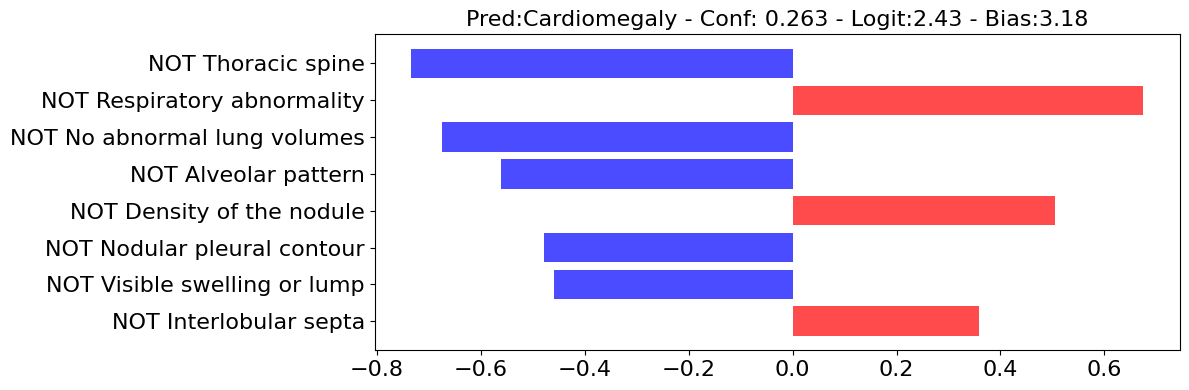

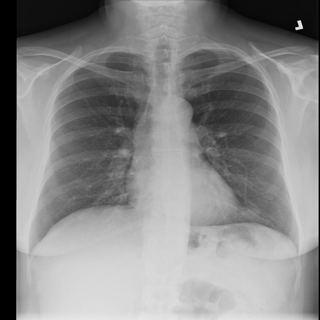

Image:22585 Ground Truth:Cardiomegaly
Pred 1: Cardiomegaly (logit: 3.701, conf: 0.725)
Pred 2: Pneumonia (logit: 1.660, conf: 0.094)
Pred 3: Atelectasis (logit: 0.727, conf: 0.037)
Pred 4: Nodule (logit: 0.532, conf: 0.031)
Pred 5: Edema (logit: 0.305, conf: 0.024)


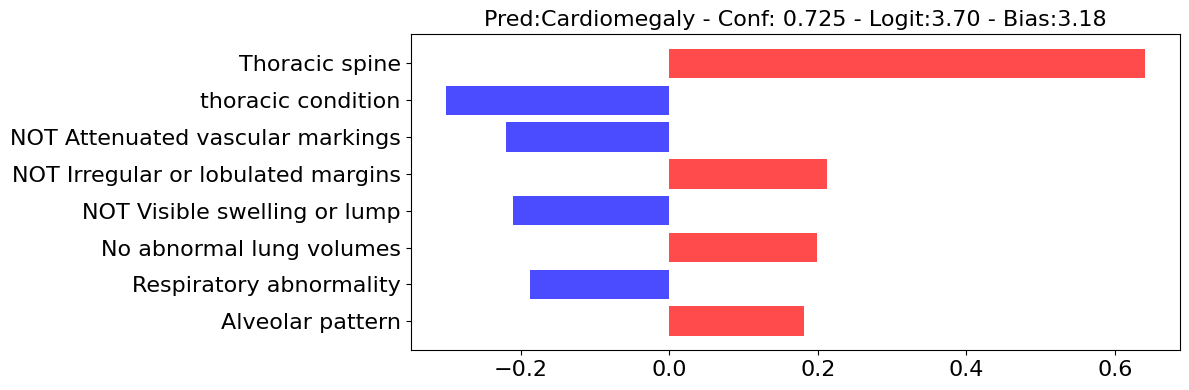

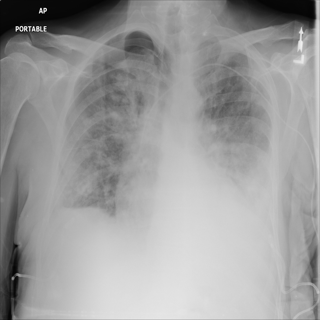

Image:9940 Ground Truth:Pneumonia
Pred 1: Cardiomegaly (logit: 2.592, conf: 0.331)
Pred 2: Atelectasis (logit: 1.806, conf: 0.151)
Pred 3: Edema (logit: 1.583, conf: 0.121)
Pred 4: Pneumonia (logit: 1.497, conf: 0.111)
Pred 5: Pneumothorax (logit: 0.885, conf: 0.060)


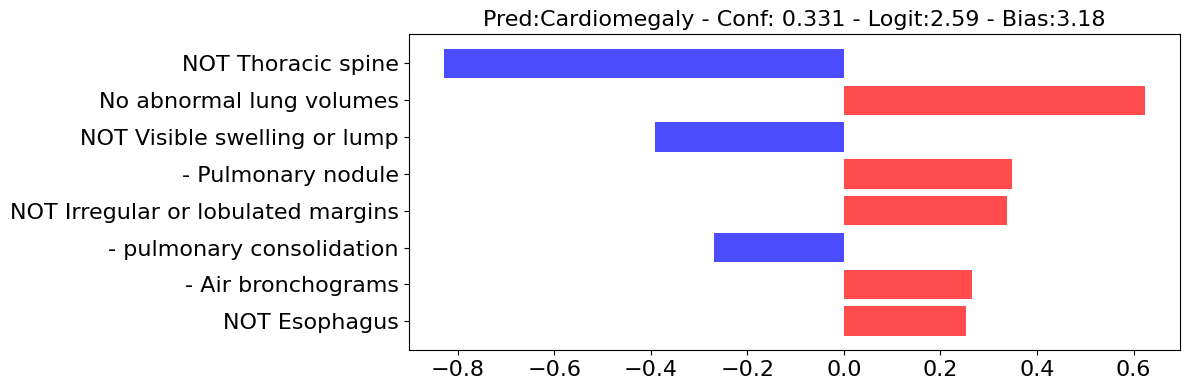

In [11]:
to_display = random.sample([i for i in range(len(val_pil_data))], k=4)

with torch.no_grad():
    for i in to_display:
        image, label = val_pil_data[i]
        x, _ = val_data_t[i]
        x = x.unsqueeze(0).to(device)
        display(image.resize([320,320]))
        
        outputs, concept_act = model(x)
        
        # Changed k from 2 to 5 for top 5 prediction
        top_logit_vals, top_classes = torch.topk(outputs[0], dim=0, k=5)
        conf = torch.nn.functional.softmax(outputs[0], dim=0)
        
        # Modified print statement to show all 5 predictions
        print(f"Image:{i} Ground Truth:{classes[int(label)]}")
        for idx in range(5):
            print(f"Pred {idx+1}: {classes[top_classes[idx]]} (logit: {top_logit_vals[idx]:.3f}, conf: {conf[top_classes[idx]]:.3f})")
        
        for k in range(1):
            contributions = concept_act[0]*model.final.weight[top_classes[k], :]
            feature_names = [("NOT " if concept_act[0][i] < 0 else "") + concepts[i] for i in range(len(concepts))]
            values = contributions.cpu().numpy()
            max_display = min(int(sum(abs(values)>0.005))+1, 8)
            title = "Pred:{} - Conf: {:.3f} - Logit:{:.2f} - Bias:{:.2f}".format(classes[top_classes[k]],
                             conf[top_classes[k]], top_logit_vals[k], model.final.bias[top_classes[k]])
            plots.bar(values, feature_names, max_display=max_display, title=title, fontsize=16)